In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)


In [ ]:
# Load the data
df = pd.read_excel('MP3.xlsx')

# Display basic info
print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\nShape: {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nCountries ({len(df)}):\n{df['Country'].tolist()}")


DATASET OVERVIEW

Shape: (37, 21)

Column Names:
['Country', 'Code', 'Num', 'FC_FSMean', 'FC_Smean', 'JI_FSMean', 'JI_Smean', 'SE_FSMean', 'SE_Smean', 'WS_FSMean', 'WS_Smean', 'WO_FSMean', 'WO_Smean', 'WH_FSMean', 'WH_Smean', 'WE_FSMean', 'WE_Smean', 'TI_FSMean', 'TI_Smean', 'TA_FSMean', 'TA_Smean']

First few rows:
      Country  Code  Num  FC_FSMean  FC_Smean  JI_FSMean  JI_Smean  SE_FSMean  \
0   Argentina     1  309  -0.209478  5.508090  -0.207716  5.838188  -0.119341   
1  Bangladesh     3  284  -0.322483  5.267606   0.060421  6.285211  -0.105834   
2      Brazil     4  348  -0.302804  5.316092  -0.193735  5.896552  -0.351872   
3      Canada     5  311   0.118271  6.064309   0.121863  6.694534   0.056546   
4       China     6  297   0.020991  5.861953   0.300683  7.154882   0.346571   

   SE_Smean  WS_FSMean  ...  WO_FSMean  WO_Smean  WH_FSMean   WH_Smean  \
0  7.896440   0.368650  ...  -0.112377  11.58900   0.199771  10.718450   
1  7.841549  -0.424532  ...  -0.450292  10.1514

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Define the 9 individual issues
issues = ['FC', 'JI', 'SE', 'WS', 'WO', 'WH', 'WE', 'TI', 'TA']

# Create feature lists
fsmean_features = [f'{issue}_FSMean' for issue in issues]
smean_features = [f'{issue}_Smean' for issue in issues]

print("="*80)
print("FEATURE PREPARATION")
print("="*80)
print(f"\n9 Individual Issues: {issues}")
print(f"\nFSMean Features: {fsmean_features}")
print(f"\nSmean Features: {smean_features}")

# Extract features
X_fsmean = df[fsmean_features].values
X_smean = df[smean_features].values

# Standardize Smean (FSMean is already standardized by IMF)
scaler = StandardScaler()
X_smean_scaled = scaler.fit_transform(X_smean)

FEATURE PREPARATION

9 Individual Issues: ['FC', 'JI', 'SE', 'WS', 'WO', 'WH', 'WE', 'TI', 'TA']

FSMean Features: ['FC_FSMean', 'JI_FSMean', 'SE_FSMean', 'WS_FSMean', 'WO_FSMean', 'WH_FSMean', 'WE_FSMean', 'TI_FSMean', 'TA_FSMean']

Smean Features: ['FC_Smean', 'JI_Smean', 'SE_Smean', 'WS_Smean', 'WO_Smean', 'WH_Smean', 'WE_Smean', 'TI_Smean', 'TA_Smean']


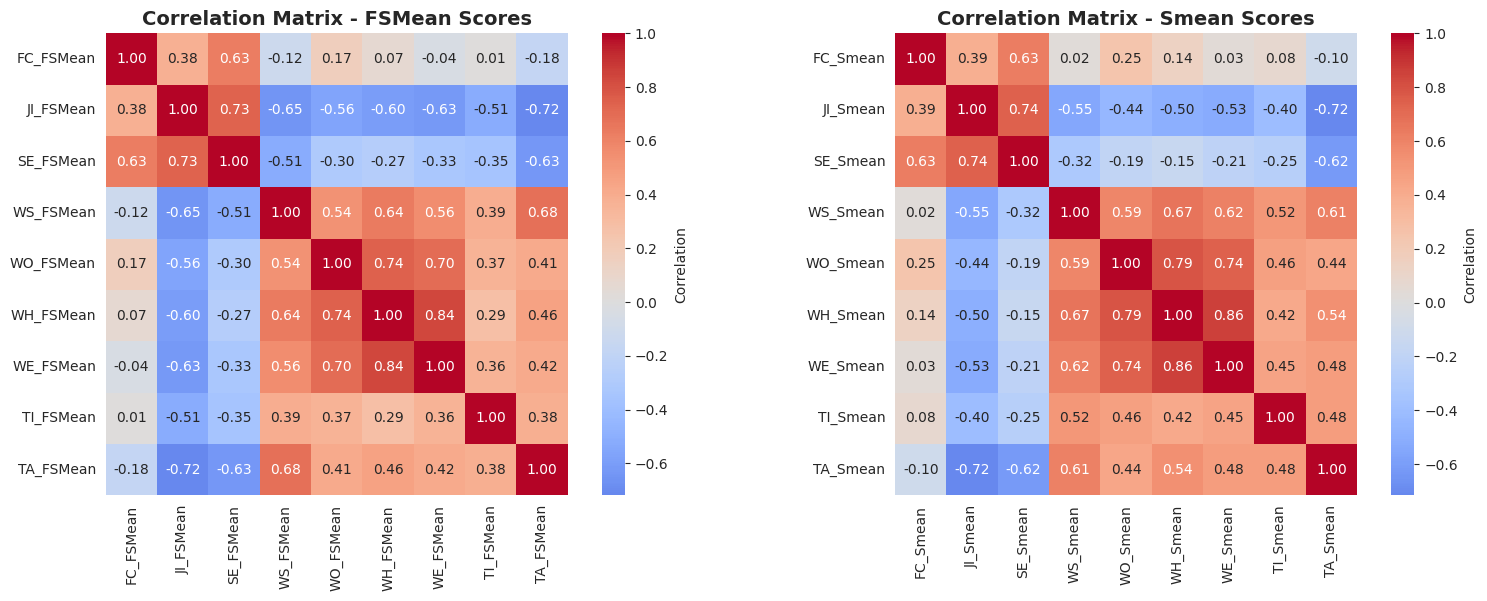


✓ Correlation heatmaps created


In [ ]:
# Create correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# FSMean correlation
corr_fsmean = df[fsmean_features].corr()
sns.heatmap(corr_fsmean, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Correlation Matrix - FSMean Scores', fontsize=14, fontweight='bold')

# Smean correlation
corr_smean = df[smean_features].corr()
sns.heatmap(corr_smean, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Correlation Matrix - Smean Scores', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Correlation heatmaps created")

In [ ]:
print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS - FSMean")
print("="*80)
stats_fsmean = df[fsmean_features].describe().round(3)
print(stats_fsmean)

print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS - Smean")
print("="*80)
stats_smean = df[smean_features].describe().round(3)
print(stats_smean)



DESCRIPTIVE STATISTICS - FSMean
       FC_FSMean  JI_FSMean  SE_FSMean  WS_FSMean  WO_FSMean  WH_FSMean  \
count     37.000     37.000     37.000     37.000     37.000     37.000   
mean      -0.008     -0.014     -0.016      0.026     -0.004     -0.014   
std        0.309      0.275      0.379      0.345      0.261      0.276   
min       -0.497     -0.713     -0.774     -0.647     -0.450     -0.735   
25%       -0.197     -0.204     -0.250     -0.257     -0.195     -0.146   
50%       -0.041     -0.046     -0.106      0.174     -0.023     -0.029   
75%        0.118      0.161      0.144      0.290      0.106      0.188   
max        0.697      0.718      1.256      0.623      0.604      0.503   

       WE_FSMean  TI_FSMean  TA_FSMean  
count     37.000     37.000     37.000  
mean      -0.000      0.012      0.022  
std        0.277      0.272      0.412  
min       -0.506     -0.470     -0.845  
25%       -0.256     -0.185     -0.224  
50%        0.006      0.006      0.058  
75% 

In [ ]:
print("\n" + "="*100)
print("COMPREHENSIVE DESCRIPTIVE STATISTICS - FSMean SCORES")
print("="*100)

# FSMean Statistics
print("\n1. SUMMARY STATISTICS (FSMean):")
print("-" * 100)
stats_fsmean = df[fsmean_features].describe().round(4)
print(stats_fsmean)

print("\n2. ADDITIONAL STATISTICS (FSMean):")
print("-" * 100)
additional_stats_fsmean = pd.DataFrame({
    'Issue': issues,
    'Mean': df[fsmean_features].mean().values,
    'Median': df[fsmean_features].median().values,
    'Std Dev': df[fsmean_features].std().values,
    'Variance': df[fsmean_features].var().values,
    'Skewness': df[fsmean_features].skew().values,
    'Kurtosis': df[fsmean_features].kurtosis().values,
    'Min': df[fsmean_features].min().values,
    'Q1': df[fsmean_features].quantile(0.25).values,
    'Q3': df[fsmean_features].quantile(0.75).values,
    'Max': df[fsmean_features].max().values,
    'Range': (df[fsmean_features].max() - df[fsmean_features].min()).values
})

# Format for better readability
for col in additional_stats_fsmean.columns[1:]:
    additional_stats_fsmean[col] = additional_stats_fsmean[col].round(4)

print(additional_stats_fsmean.to_string(index=False))

print("\n" + "="*100)
print("COMPREHENSIVE DESCRIPTIVE STATISTICS - Smean SCORES")
print("="*100)

# Smean Statistics
print("\n1. SUMMARY STATISTICS (Smean):")
print("-" * 100)
stats_smean = df[smean_features].describe().round(4)
print(stats_smean)

print("\n2. ADDITIONAL STATISTICS (Smean):")
print("-" * 100)
additional_stats_smean = pd.DataFrame({
    'Issue': issues,
    'Mean': df[smean_features].mean().values,
    'Median': df[smean_features].median().values,
    'Std Dev': df[smean_features].std().values,
    'Variance': df[smean_features].var().values,
    'Skewness': df[smean_features].skew().values,
    'Kurtosis': df[smean_features].kurtosis().values,
    'Min': df[smean_features].min().values,
    'Q1': df[smean_features].quantile(0.25).values,
    'Q3': df[smean_features].quantile(0.75).values,
    'Max': df[smean_features].max().values,
    'Range': (df[smean_features].max() - df[smean_features].min()).values
})

# Format for better readability
for col in additional_stats_smean.columns[1:]:
    additional_stats_smean[col] = additional_stats_smean[col].round(4)

print(additional_stats_smean.to_string(index=False))

print("\n" + "="*100)
print("INTERPRETATION OF DESCRIPTIVE STATISTICS")
print("="*100)

print("\nKey Measures:")
print("  • Mean: Average value of the issue across all countries")
print("  • Median: Middle value (50th percentile) - robust to outliers")
print("  • Std Dev: Spread of data (higher = more variation across countries)")
print("  • Skewness: Distribution shape (-1 to +1, 0 = symmetric)")
print("  • Kurtosis: Tail behavior (outliers present)")
print("  • Range: Difference between max and min")
print("  • Q1/Q3: 25th and 75th percentiles")

print("\n" + "-"*100)
print("ISSUE-BY-ISSUE INSIGHTS (FSMean):")
print("-"*100)

for idx, issue in enumerate(issues):
    fsmean_col = fsmean_features[idx]
    smean_col = smean_features[idx]

    print(f"\n{idx+1}. {issue} (Individual Issue):")
    print(f"   FSMean - Mean: {df[fsmean_col].mean():.4f}, Std: {df[fsmean_col].std():.4f}, Range: [{df[fsmean_col].min():.4f}, {df[fsmean_col].max():.4f}]")
    print(f"   Smean  - Mean: {df[smean_col].mean():.4f}, Std: {df[smean_col].std():.4f}, Range: [{df[smean_col].min():.4f}, {df[smean_col].max():.4f}]")

    # Identify high and low countries
    max_country_fsmean = df.loc[df[fsmean_col].idxmax(), 'Country']
    min_country_fsmean = df.loc[df[fsmean_col].idxmin(), 'Country']
    print(f"   Extremes: Highest = {max_country_fsmean} ({df[fsmean_col].max():.4f}), Lowest = {min_country_fsmean} ({df[fsmean_col].min():.4f})")

print("\n" + "="*100)



COMPREHENSIVE DESCRIPTIVE STATISTICS - FSMean SCORES

1. SUMMARY STATISTICS (FSMean):
----------------------------------------------------------------------------------------------------
       FC_FSMean  JI_FSMean  SE_FSMean  WS_FSMean  WO_FSMean  WH_FSMean  \
count    37.0000    37.0000    37.0000    37.0000    37.0000    37.0000   
mean     -0.0077    -0.0143    -0.0155     0.0264    -0.0036    -0.0139   
std       0.3094     0.2753     0.3786     0.3450     0.2614     0.2759   
min      -0.4966    -0.7132    -0.7737    -0.6470    -0.4503    -0.7347   
25%      -0.1973    -0.2042    -0.2499    -0.2566    -0.1952    -0.1456   
50%      -0.0413    -0.0461    -0.1058     0.1742    -0.0229    -0.0293   
75%       0.1183     0.1614     0.1437     0.2904     0.1057     0.1882   
max       0.6974     0.7175     1.2559     0.6225     0.6041     0.5033   

       WE_FSMean  TI_FSMean  TA_FSMean  
count    37.0000    37.0000    37.0000  
mean     -0.0003     0.0116     0.0215  
std       0.2

In [ ]:
print("\n" + "="*100)
print("SUMMARY TABLE: ALL 9 ISSUES - FSMean vs Smean")
print("="*100)

# Create comprehensive comparison table
comparison_data = []

for idx, issue in enumerate(issues):
    fsmean_col = fsmean_features[idx]
    smean_col = smean_features[idx]

    comparison_data.append({
        'Issue': issue,
        'FSMean_Mean': df[fsmean_col].mean(),
        'FSMean_Std': df[fsmean_col].std(),
        'FSMean_Min': df[fsmean_col].min(),
        'FSMean_Max': df[fsmean_col].max(),
        'Smean_Mean': df[smean_col].mean(),
        'Smean_Std': df[smean_col].std(),
        'Smean_Min': df[smean_col].min(),
        'Smean_Max': df[smean_col].max(),
        'Correlation': df[fsmean_col].corr(df[smean_col])
    })

comparison_df = pd.DataFrame(comparison_data)

# Format for display
for col in comparison_df.columns[1:]:
    comparison_df[col] = comparison_df[col].round(4)

print("\n" + comparison_df.to_string(index=False))

print("\n\nISSUE DEFINITIONS (From IMF):")
print("-" * 100)
issue_definitions = {
    'FC': 'Dependence/Use of Friendship Circles (social capital & workplace support)',
    'JI': 'Job Insecurity (threat to job features and employment stability)',
    'SE': 'Self-efficacy (capability to successfully complete professional tasks)',
    'WS': 'Work Satisfaction (positive emotional state about work)',
    'WO': 'Work Overload (excessive workload and responsibilities)',
    'WH': 'Work-Home Conflict (balance between work and personal life)',
    'WE': 'Work Exhaustion (burnout and fatigue)',
    'TI': 'Turnover Intention (intention to leave the organization)',
    'TA': 'Turnaway Intention (attractiveness of ICT profession)'
}

for issue, definition in issue_definitions.items():
    print(f"\n{issue}: {definition}")



SUMMARY TABLE: ALL 9 ISSUES - FSMean vs Smean

Issue  FSMean_Mean  FSMean_Std  FSMean_Min  FSMean_Max  Smean_Mean  Smean_Std  Smean_Min  Smean_Max  Correlation
   FC      -0.0077      0.3094     -0.4966      0.6974      5.8256     0.5163     5.0323     6.9806       0.9978
   JI      -0.0143      0.2753     -0.7132      0.7175      6.2919     0.6909     4.5886     8.1401       0.9858
   SE      -0.0155      0.3786     -0.7737      1.2559      8.1230     1.0761     6.0371    11.7227       0.9874
   WS       0.0264      0.3450     -0.6470      0.6225     13.4319     1.0760    11.1075    15.7657       0.9273
   WO      -0.0036      0.2614     -0.4503      0.6041     11.9015     0.9936     9.1720    14.1000       0.9716
   WH      -0.0139      0.2759     -0.7347      0.5033     10.0124     0.9220     7.1290    11.6604       0.9785
   WE      -0.0003      0.2769     -0.5058      0.6331     12.7574     1.1761     9.4839    15.3522       0.9812
   TI       0.0116      0.2720     -0.4702      

In [ ]:
print("\n" + "="*100)
print("COUNTRY-LEVEL DESCRIPTIVE STATISTICS")
print("="*100)

# Calculate average score for each country across all issues
df['FSMean_Average'] = df[fsmean_features].mean(axis=1)
df['Smean_Average'] = df[smean_features].mean(axis=1)

# Create country summary
country_summary = df[['Country', 'FSMean_Average', 'Smean_Average']].copy()
country_summary = country_summary.sort_values('FSMean_Average', ascending=False)
country_summary['FSMean_Average'] = country_summary['FSMean_Average'].round(4)
country_summary['Smean_Average'] = country_summary['Smean_Average'].round(4)
country_summary['Rank_FSMean'] = range(1, len(country_summary) + 1)

print("\nCountries Ranked by Average FSMean Score (Higher = More Favorable ICT Worker Conditions):")
print("-" * 100)
print(country_summary.to_string(index=False))

print("\n\nTOP 5 COUNTRIES (Highest Average FSMean):")
print("-" * 100)
top5 = country_summary.head(5)
for idx, row in top5.iterrows():
    print(f"{row['Rank_FSMean']}. {row['Country']}: {row['FSMean_Average']:.4f}")

print("\n\nBOTTOM 5 COUNTRIES (Lowest Average FSMean):")
print("-" * 100)
bottom5 = country_summary.tail(5)
for idx, row in bottom5.iterrows():
    print(f"{country_summary.shape[0] - row['Rank_FSMean'] + 1}. {row['Country']}: {row['FSMean_Average']:.4f}")



COUNTRY-LEVEL DESCRIPTIVE STATISTICS

Countries Ranked by Average FSMean Score (Higher = More Favorable ICT Worker Conditions):
----------------------------------------------------------------------------------------------------
     Country  FSMean_Average  Smean_Average  Rank_FSMean
      Poland          0.2363        10.7404            1
     Germany          0.2252        10.3402            2
   Lithuania          0.1852        10.5563            3
     Hungary          0.1507        10.4685            4
        Peru          0.1484        10.5444            5
       Japan          0.1463        10.2599            6
       India          0.1378        10.6057            7
     Finland          0.0911        10.1312            8
         USA          0.0813        10.2316            9
    Portugal          0.0765        10.2068           10
        Iran          0.0676        10.1575           11
   Argentina          0.0565        10.1744           12
      Mexico          0.0542 

In [ ]:
print("\n" + "="*100)
print("OUTLIER DETECTION - Z-SCORE METHOD")
print("="*100)

from scipy import stats

# Calculate Z-scores for each issue
z_scores = np.abs(stats.zscore(df[fsmean_features]))

# Identify outliers (|Z-score| > 3)
outlier_threshold = 3
outliers_df = pd.DataFrame({
    'Country': df['Country'],
    'Max_Z_Score': z_scores.max(axis=1),
    'Issue_with_Outlier': [fsmean_features[z_scores[i].argmax()] if z_scores[i].max() > outlier_threshold else 'None'
                           for i in range(len(df))]
})

outliers_df = outliers_df[outliers_df['Max_Z_Score'] > outlier_threshold].sort_values('Max_Z_Score', ascending=False)

if len(outliers_df) > 0:
    print(f"\nCountries with Potential Outliers (|Z-score| > {outlier_threshold}):")
    print("-" * 100)
    print(outliers_df.to_string(index=False))
    print(f"\nTotal outlier countries: {len(outliers_df)} out of {len(df)}")
else:
    print(f"\n✓ No significant outliers detected (all |Z-scores| ≤ {outlier_threshold})")

# Moderate outliers (Z-score between 2 and 3)
moderate_outliers = pd.DataFrame({
    'Country': df['Country'],
    'Max_Z_Score': z_scores.max(axis=1),
})
moderate_outliers = moderate_outliers[(moderate_outliers['Max_Z_Score'] > 2) &
                                       (moderate_outliers['Max_Z_Score'] <= 3)].sort_values('Max_Z_Score', ascending=False)

if len(moderate_outliers) > 0:
    print(f"\n\nCountries with Moderate Outliers (2 < |Z-score| ≤ 3):")
    print("-" * 100)
    print(moderate_outliers.to_string(index=False))



OUTLIER DETECTION - Z-SCORE METHOD

Countries with Potential Outliers (|Z-score| > 3):
----------------------------------------------------------------------------------------------------
Country  Max_Z_Score Issue_with_Outlier
   Iran     3.404774          SE_FSMean

Total outlier countries: 1 out of 37


Countries with Moderate Outliers (2 < |Z-score| ≤ 3):
----------------------------------------------------------------------------------------------------
    Country  Max_Z_Score
   Pakistan     2.648872
      Italy     2.599491
      India     2.573444
      Japan     2.375447
     Poland     2.356865
       Peru     2.318772
    Nigeria     2.184857
      Ghana     2.134316
South Korea     2.037473
    Hungary     2.015104


In [ ]:
print("\n" + "="*100)
print("VARIABILITY ANALYSIS - COEFFICIENT OF VARIATION")
print("="*100)

# Calculate coefficient of variation (CV = Std/Mean * 100)
cv_fsmean = (df[fsmean_features].std() / df[fsmean_features].mean().abs() * 100)
cv_smean = (df[smean_features].std() / df[smean_features].mean().abs() * 100)

print("\nCoefficient of Variation (CV) - Measures relative variability across countries")
print("Higher CV = More variation in that issue across countries")
print("Lower CV = More consistent across countries")
print("-" * 100)

cv_data = pd.DataFrame({
    'Issue': issues,
    'CV_FSMean': cv_fsmean.values.round(2),
    'CV_Smean': cv_smean.values.round(2)
})

# Sort by FSMean CV (descending)
cv_data_sorted = cv_data.sort_values('CV_FSMean', ascending=False)
print("\n" + cv_data_sorted.to_string(index=False))

print("\n\nInterpretation:")
print("  • High CV (>30%): This issue varies significantly across countries")
print("  • Medium CV (15-30%): Moderate variation across countries")
print("  • Low CV (<15%): Relatively consistent across countries")

# Identify most and least variable issues
most_variable = cv_data_sorted.iloc[0]
least_variable = cv_data_sorted.iloc[-1]

print(f"\n✓ Most Variable Issue: {most_variable['Issue']} (CV = {most_variable['CV_FSMean']:.2f}%)")
print(f"✓ Least Variable Issue: {least_variable['Issue']} (CV = {least_variable['CV_FSMean']:.2f}%")


VARIABILITY ANALYSIS - COEFFICIENT OF VARIATION

Coefficient of Variation (CV) - Measures relative variability across countries
Higher CV = More variation in that issue across countries
Lower CV = More consistent across countries
----------------------------------------------------------------------------------------------------

Issue  CV_FSMean  CV_Smean
   WE   93569.00      9.22
   WO    7190.38      8.35
   FC    4029.84      8.86
   SE    2439.27     13.25
   TI    2352.46      7.95
   WH    1987.00      9.21
   JI    1929.72     10.98
   TA    1914.24      9.44
   WS    1304.46      8.01


Interpretation:
  • High CV (>30%): This issue varies significantly across countries
  • Medium CV (15-30%): Moderate variation across countries
  • Low CV (<15%): Relatively consistent across countries

✓ Most Variable Issue: WE (CV = 93569.00%)
✓ Least Variable Issue: WS (CV = 1304.46%


In [ ]:
print("\n" + "="*100)
print("EXPORTING DESCRIPTIVE STATISTICS")
print("="*100)

# Export comprehensive statistics
stats_fsmean.to_csv('descriptive_stats_fsmean.csv')
print("✓ FSMean statistics exported to 'descriptive_stats_fsmean.csv'")

stats_smean.to_csv('descriptive_stats_smean.csv')
print("✓ Smean statistics exported to 'descriptive_stats_smean.csv'")

additional_stats_fsmean.to_csv('additional_stats_fsmean.csv', index=False)
print("✓ Additional FSMean statistics exported to 'additional_stats_fsmean.csv'")

additional_stats_smean.to_csv('additional_stats_smean.csv', index=False)
print("✓ Additional Smean statistics exported to 'additional_stats_smean.csv'")

comparison_df.to_csv('issue_comparison_stats.csv', index=False)
print("✓ Issue comparison statistics exported to 'issue_comparison_stats.csv'")

country_summary.to_csv('country_average_scores.csv', index=False)
print("✓ Country averages exported to 'country_average_scores.csv'")

cv_data_sorted.to_csv('coefficient_of_variation.csv', index=False)
print("✓ Coefficient of variation exported to 'coefficient_of_variation.csv'")

print("\n✓ All descriptive statistics exported successfully!")



EXPORTING DESCRIPTIVE STATISTICS
✓ FSMean statistics exported to 'descriptive_stats_fsmean.csv'
✓ Smean statistics exported to 'descriptive_stats_smean.csv'
✓ Additional FSMean statistics exported to 'additional_stats_fsmean.csv'
✓ Additional Smean statistics exported to 'additional_stats_smean.csv'
✓ Issue comparison statistics exported to 'issue_comparison_stats.csv'
✓ Country averages exported to 'country_average_scores.csv'
✓ Coefficient of variation exported to 'coefficient_of_variation.csv'

✓ All descriptive statistics exported successfully!



CREATING BOXPLOTS FOR DESCRIPTIVE STATISTICS VISUALIZATION


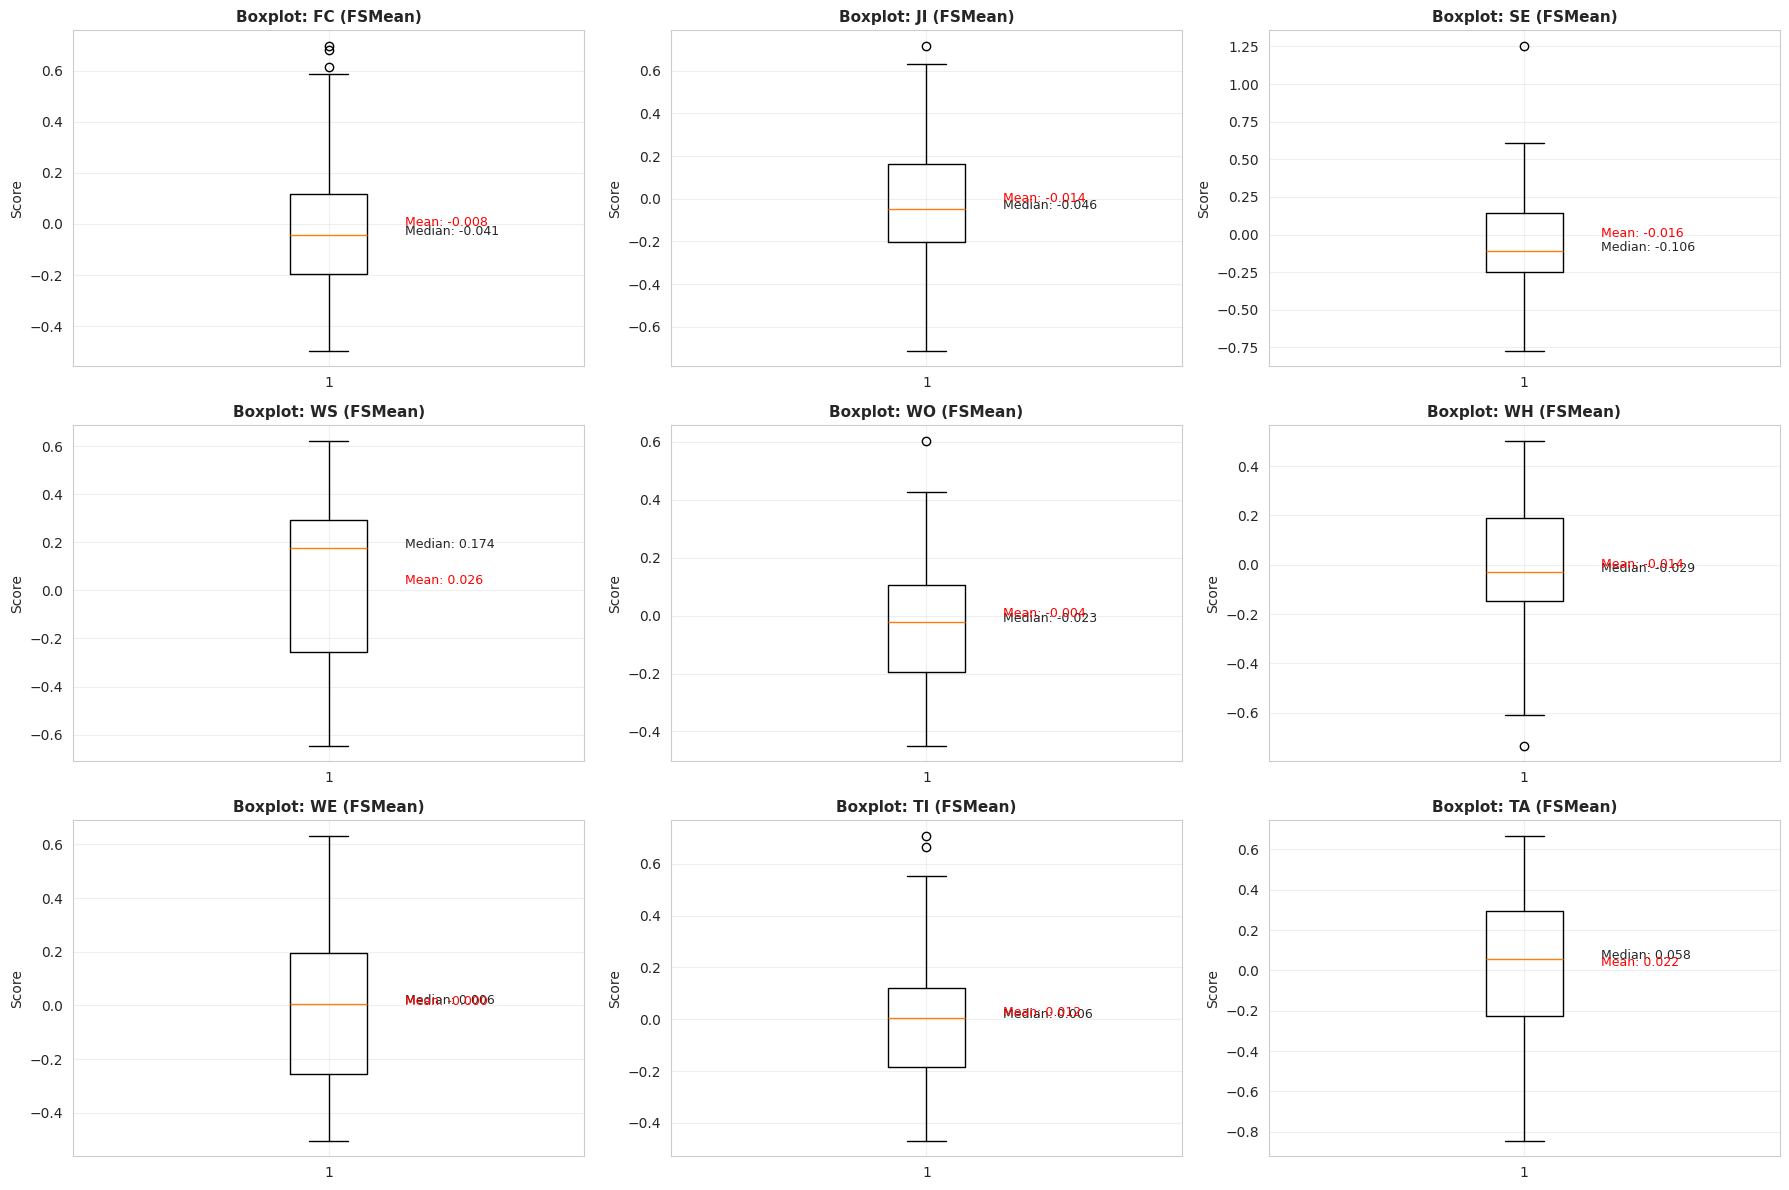

✓ Boxplots created and saved as 'boxplots_descriptive_stats.png'


In [ ]:
print("\n" + "="*100)
print("CREATING BOXPLOTS FOR DESCRIPTIVE STATISTICS VISUALIZATION")
print("="*100)

# Create boxplots for all 9 issues
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (fsmean_col, issue) in enumerate(zip(fsmean_features, issues)):
    axes[i].boxplot(df[fsmean_col], vert=True)
    axes[i].set_title(f'Boxplot: {issue} (FSMean)', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Score')
    axes[i].grid(True, alpha=0.3)

    # Add statistics to plot
    median = df[fsmean_col].median()
    mean = df[fsmean_col].mean()
    axes[i].text(1.15, median, f'Median: {median:.3f}', fontsize=9)
    axes[i].text(1.15, mean, f'Mean: {mean:.3f}', fontsize=9, color='red')

plt.tight_layout()
plt.savefig('boxplots_descriptive_stats.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Boxplots created and saved as 'boxplots_descriptive_stats.png'")


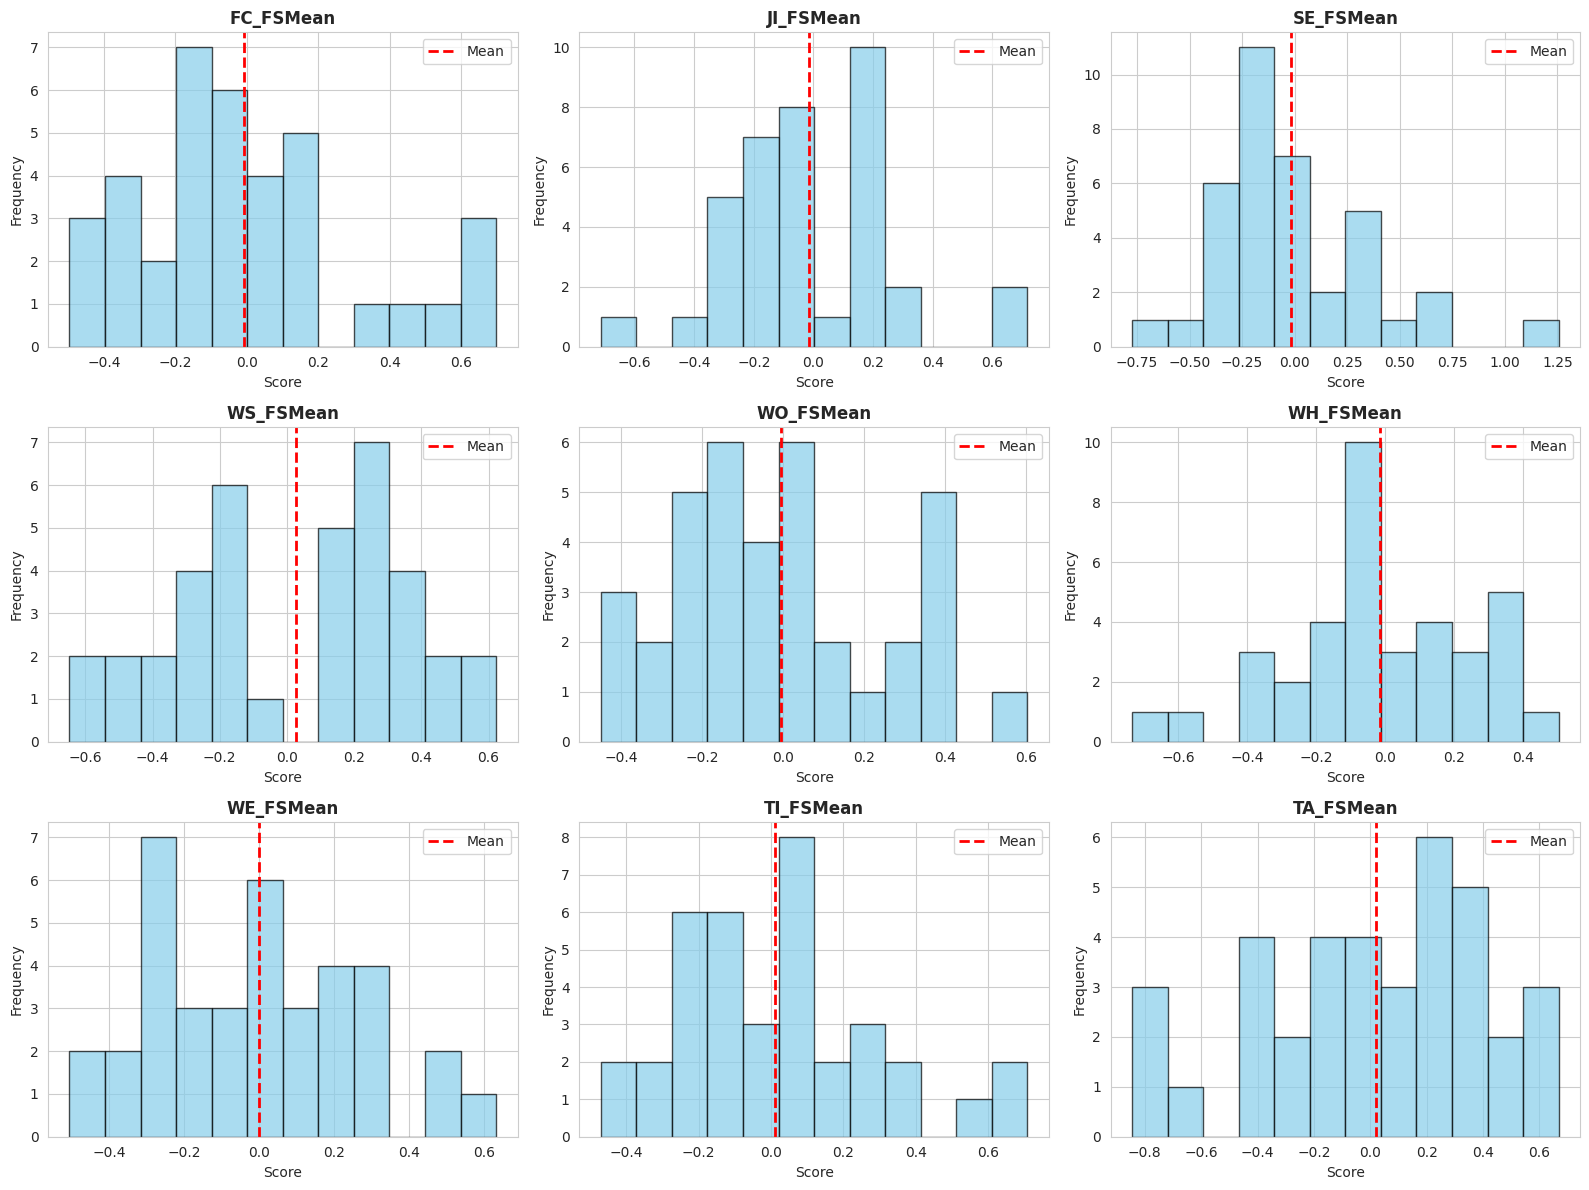

✓ FSMean distribution plots created


In [ ]:
# FSMean distributions
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(fsmean_features):
    axes[i].hist(df[feature], bins=12, edgecolor='black', alpha=0.7, color='skyblue')
    axes[i].set_title(f'{feature}', fontweight='bold')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[feature].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    axes[i].legend()

plt.tight_layout()
plt.savefig('fsmean_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ FSMean distribution plots created")


In [ ]:
print("\n" + "="*80)
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*80)

# Ensure X_smean is defined and scaled for this cell
# This section is added to make the cell self-contained, in case previous cells were not run.
if 'X_smean' not in locals():
    X_smean = df[smean_features].values
    scaler = StandardScaler()
    X_smean_scaled = scaler.fit_transform(X_smean)
elif 'X_smean_scaled' not in locals():
    scaler = StandardScaler()
    X_smean_scaled = scaler.fit_transform(X_smean)

# Calculate WCSS and silhouette scores for FSMean
wcss_fsmean = []
silhouette_scores_fsmean = []
K_range = range(2, 11)

print("\nFSMean - Testing different k values:")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=25, max_iter=300)
    kmeans.fit(X_fsmean)
    wcss_fsmean.append(kmeans.inertia_)
    sil_score = silhouette_score(X_fsmean, kmeans.labels_)
    silhouette_scores_fsmean.append(sil_score)
    print(f"  k={k}: WCSS={kmeans.inertia_:.2f}, Silhouette={sil_score:.4f}")

# Calculate WCSS and silhouette scores for Smean
wcss_smean = []
silhouette_scores_smean = []

print("\nSmean - Testing different k values:")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=25, max_iter=300)
    kmeans.fit(X_smean_scaled)
    wcss_smean.append(kmeans.inertia_)
    sil_score = silhouette_score(X_smean_scaled, kmeans.labels_)
    silhouette_scores_smean.append(sil_score)
    print(f"  k={k}: WCSS={kmeans.inertia_:.2f}, Silhouette={sil_score:.4f}")

# Find optimal k
optimal_k_fsmean = list(K_range)[np.argmax(silhouette_scores_fsmean)]
optimal_k_smean = list(K_range)[np.argmax(silhouette_scores_smean)]

print(f"\n✓ Optimal k (FSMean - Silhouette): {optimal_k_fsmean} (Score: {max(silhouette_scores_fsmean):.4f})")
print(f"✓ Optimal k (Smean - Silhouette): {optimal_k_smean} (Score: {max(silhouette_scores_smean):.4f})")


DETERMINING OPTIMAL NUMBER OF CLUSTERS

FSMean - Testing different k values:
  k=2: WCSS=18.83, Silhouette=0.3451
  k=3: WCSS=15.69, Silhouette=0.3202
  k=4: WCSS=13.94, Silhouette=0.2384
  k=5: WCSS=12.20, Silhouette=0.1821
  k=6: WCSS=11.30, Silhouette=0.2002
  k=7: WCSS=10.01, Silhouette=0.2049
  k=8: WCSS=8.75, Silhouette=0.1992
  k=9: WCSS=7.75, Silhouette=0.1683
  k=10: WCSS=7.00, Silhouette=0.1785

Smean - Testing different k values:
  k=2: WCSS=205.55, Silhouette=0.3177
  k=3: WCSS=166.24, Silhouette=0.2981
  k=4: WCSS=143.81, Silhouette=0.1971
  k=5: WCSS=121.96, Silhouette=0.1994
  k=6: WCSS=108.40, Silhouette=0.2010
  k=7: WCSS=96.29, Silhouette=0.1898
  k=8: WCSS=88.54, Silhouette=0.1826
  k=9: WCSS=80.35, Silhouette=0.1797
  k=10: WCSS=72.59, Silhouette=0.1691

✓ Optimal k (FSMean - Silhouette): 2 (Score: 0.3451)
✓ Optimal k (Smean - Silhouette): 2 (Score: 0.3177)


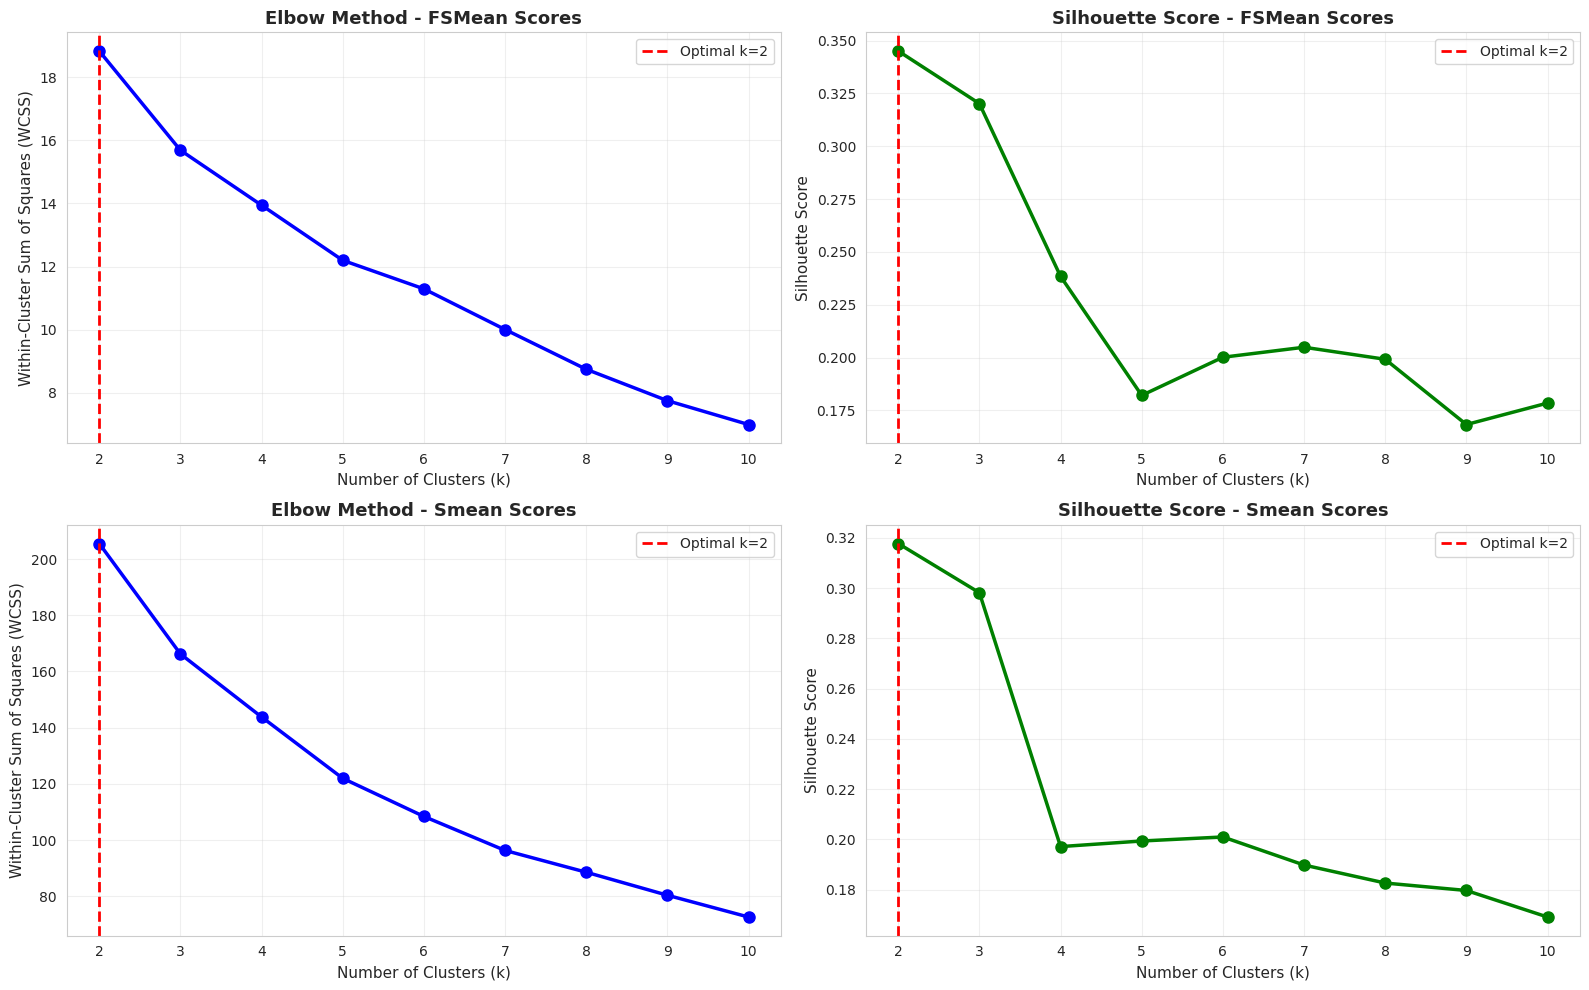

✓ Elbow and silhouette plots created


In [ ]:
# Plot elbow and silhouette curves
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# FSMean Elbow
axes[0, 0].plot(K_range, wcss_fsmean, 'bo-', linewidth=2.5, markersize=8)
axes[0, 0].axvline(optimal_k_fsmean, color='red', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k_fsmean}')
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0, 0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=11)
axes[0, 0].set_title('Elbow Method - FSMean Scores', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=10)

# FSMean Silhouette
axes[0, 1].plot(K_range, silhouette_scores_fsmean, 'go-', linewidth=2.5, markersize=8)
axes[0, 1].axvline(optimal_k_fsmean, color='red', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k_fsmean}')
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=11)
axes[0, 1].set_title('Silhouette Score - FSMean Scores', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=10)

# Smean Elbow
axes[1, 0].plot(K_range, wcss_smean, 'bo-', linewidth=2.5, markersize=8)
axes[1, 0].axvline(optimal_k_smean, color='red', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k_smean}')
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1, 0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=11)
axes[1, 0].set_title('Elbow Method - Smean Scores', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=10)

# Smean Silhouette
axes[1, 1].plot(K_range, silhouette_scores_smean, 'go-', linewidth=2.5, markersize=8)
axes[1, 1].axvline(optimal_k_smean, color='red', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k_smean}')
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1, 1].set_ylabel('Silhouette Score', fontsize=11)
axes[1, 1].set_title('Silhouette Score - Smean Scores', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('optimal_clusters_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Elbow and silhouette plots created")


In [ ]:
# For this analysis, let's use the optimal k from silhouette analysis
# You can adjust this based on your preference
chosen_k = optimal_k_fsmean

print("\n" + "="*80)
print(f"FINAL CLUSTERING DECISION: k = {chosen_k}")
print("="*80)
print(f"\nJustification:")
print(f"  - FSMean optimal k (silhouette): {optimal_k_fsmean} with score {max(silhouette_scores_fsmean):.4f}")
print(f"  - Smean optimal k (silhouette): {optimal_k_smean} with score {max(silhouette_scores_smean):.4f}")
print(f"  - Selected k: {chosen_k} (highest silhouette score)")



FINAL CLUSTERING DECISION: k = 2

Justification:
  - FSMean optimal k (silhouette): 2 with score 0.3451
  - Smean optimal k (silhouette): 2 with score 0.3177
  - Selected k: 2 (highest silhouette score)


In [ ]:
print("\n" + "="*80)
print("K-MEANS CLUSTERING - FSMean")
print("="*80)

# Perform K-Means on FSMean
kmeans_fsmean = KMeans(n_clusters=chosen_k, random_state=42, n_init=25, max_iter=300)
df['Cluster_KMeans_FSMean'] = kmeans_fsmean.fit_predict(X_fsmean)

# Calculate validation metrics
sil_kmeans_fsmean = silhouette_score(X_fsmean, df['Cluster_KMeans_FSMean'])
db_kmeans_fsmean = davies_bouldin_score(X_fsmean, df['Cluster_KMeans_FSMean'])
ch_kmeans_fsmean = calinski_harabasz_score(X_fsmean, df['Cluster_KMeans_FSMean'])

print(f"\nValidation Metrics:")
print(f"  Silhouette Score:      {sil_kmeans_fsmean:.4f}")
print(f"  Davies-Bouldin Index:  {db_kmeans_fsmean:.4f} (lower is better)")
print(f"  Calinski-Harabasz:     {ch_kmeans_fsmean:.2f} (higher is better)")

# Cluster sizes
print(f"\nCluster Sizes:")
for i in range(chosen_k):
    count = (df['Cluster_KMeans_FSMean'] == i).sum()
    print(f"  Cluster {i}: {count} countries")



K-MEANS CLUSTERING - FSMean

Validation Metrics:
  Silhouette Score:      0.3451
  Davies-Bouldin Index:  1.1026 (lower is better)
  Calinski-Harabasz:     25.14 (higher is better)

Cluster Sizes:
  Cluster 0: 17 countries
  Cluster 1: 20 countries


In [ ]:
print("\n" + "="*80)
print("K-MEANS CLUSTERING - Smean")
print("="*80)

# Perform K-Means on Smean
kmeans_smean = KMeans(n_clusters=chosen_k, random_state=42, n_init=25, max_iter=300)
df['Cluster_KMeans_Smean'] = kmeans_smean.fit_predict(X_smean_scaled)

# Calculate validation metrics
sil_kmeans_smean = silhouette_score(X_smean_scaled, df['Cluster_KMeans_Smean'])
db_kmeans_smean = davies_bouldin_score(X_smean_scaled, df['Cluster_KMeans_Smean'])
ch_kmeans_smean = calinski_harabasz_score(X_smean_scaled, df['Cluster_KMeans_Smean'])

print(f"\nValidation Metrics:")
print(f"  Silhouette Score:      {sil_kmeans_smean:.4f}")
print(f"  Davies-Bouldin Index:  {db_kmeans_smean:.4f} (lower is better)")
print(f"  Calinski-Harabasz:     {ch_kmeans_smean:.2f} (higher is better)")

# Cluster sizes
print(f"\nCluster Sizes:")
for i in range(chosen_k):
    count = (df['Cluster_KMeans_Smean'] == i).sum()
    print(f"  Cluster {i}: {count} countries")



K-MEANS CLUSTERING - Smean

Validation Metrics:
  Silhouette Score:      0.3177
  Davies-Bouldin Index:  1.1723 (lower is better)
  Calinski-Harabasz:     21.70 (higher is better)

Cluster Sizes:
  Cluster 0: 17 countries
  Cluster 1: 20 countries


In [ ]:
print("\n" + "="*80)
print("HIERARCHICAL CLUSTERING - FSMean (Ward Method)")
print("="*80)

# Perform Hierarchical Clustering
hc_fsmean = AgglomerativeClustering(n_clusters=chosen_k, linkage='ward')
df['Cluster_HC_FSMean'] = hc_fsmean.fit_predict(X_fsmean)

# Calculate validation metrics
sil_hc_fsmean = silhouette_score(X_fsmean, df['Cluster_HC_FSMean'])
db_hc_fsmean = davies_bouldin_score(X_fsmean, df['Cluster_HC_FSMean'])
ch_hc_fsmean = calinski_harabasz_score(X_fsmean, df['Cluster_HC_FSMean'])

print(f"\nValidation Metrics:")
print(f"  Silhouette Score:      {sil_hc_fsmean:.4f}")
print(f"  Davies-Bouldin Index:  {db_hc_fsmean:.4f}")
print(f"  Calinski-Harabasz:     {ch_hc_fsmean:.2f}")

# Cluster sizes
print(f"\nCluster Sizes:")
for i in range(chosen_k):
    count = (df['Cluster_HC_FSMean'] == i).sum()
    print(f"  Cluster {i}: {count} countries")



HIERARCHICAL CLUSTERING - FSMean (Ward Method)

Validation Metrics:
  Silhouette Score:      0.3451
  Davies-Bouldin Index:  1.1026
  Calinski-Harabasz:     25.14

Cluster Sizes:
  Cluster 0: 17 countries
  Cluster 1: 20 countries


In [ ]:
print("\n" + "="*80)
print("HIERARCHICAL CLUSTERING - Smean (Ward Method)")
print("="*80)

# Perform Hierarchical Clustering
hc_smean = AgglomerativeClustering(n_clusters=chosen_k, linkage='ward')
df['Cluster_HC_Smean'] = hc_smean.fit_predict(X_smean_scaled)

# Calculate validation metrics
sil_hc_smean = silhouette_score(X_smean_scaled, df['Cluster_HC_Smean'])
db_hc_smean = davies_bouldin_score(X_smean_scaled, df['Cluster_HC_Smean'])
ch_hc_smean = calinski_harabasz_score(X_smean_scaled, df['Cluster_HC_Smean'])

print(f"\nValidation Metrics:")
print(f"  Silhouette Score:      {sil_hc_smean:.4f}")
print(f"  Davies-Bouldin Index:  {db_hc_smean:.4f}")
print(f"  Calinski-Harabasz:     {ch_hc_smean:.2f}")

# Cluster sizes
print(f"\nCluster Sizes:")
for i in range(chosen_k):
    count = (df['Cluster_HC_Smean'] == i).sum()
    print(f"  Cluster {i}: {count} countries")



HIERARCHICAL CLUSTERING - Smean (Ward Method)

Validation Metrics:
  Silhouette Score:      0.3177
  Davies-Bouldin Index:  1.1723
  Calinski-Harabasz:     21.70

Cluster Sizes:
  Cluster 0: 17 countries
  Cluster 1: 20 countries



CREATING DENDROGRAMS


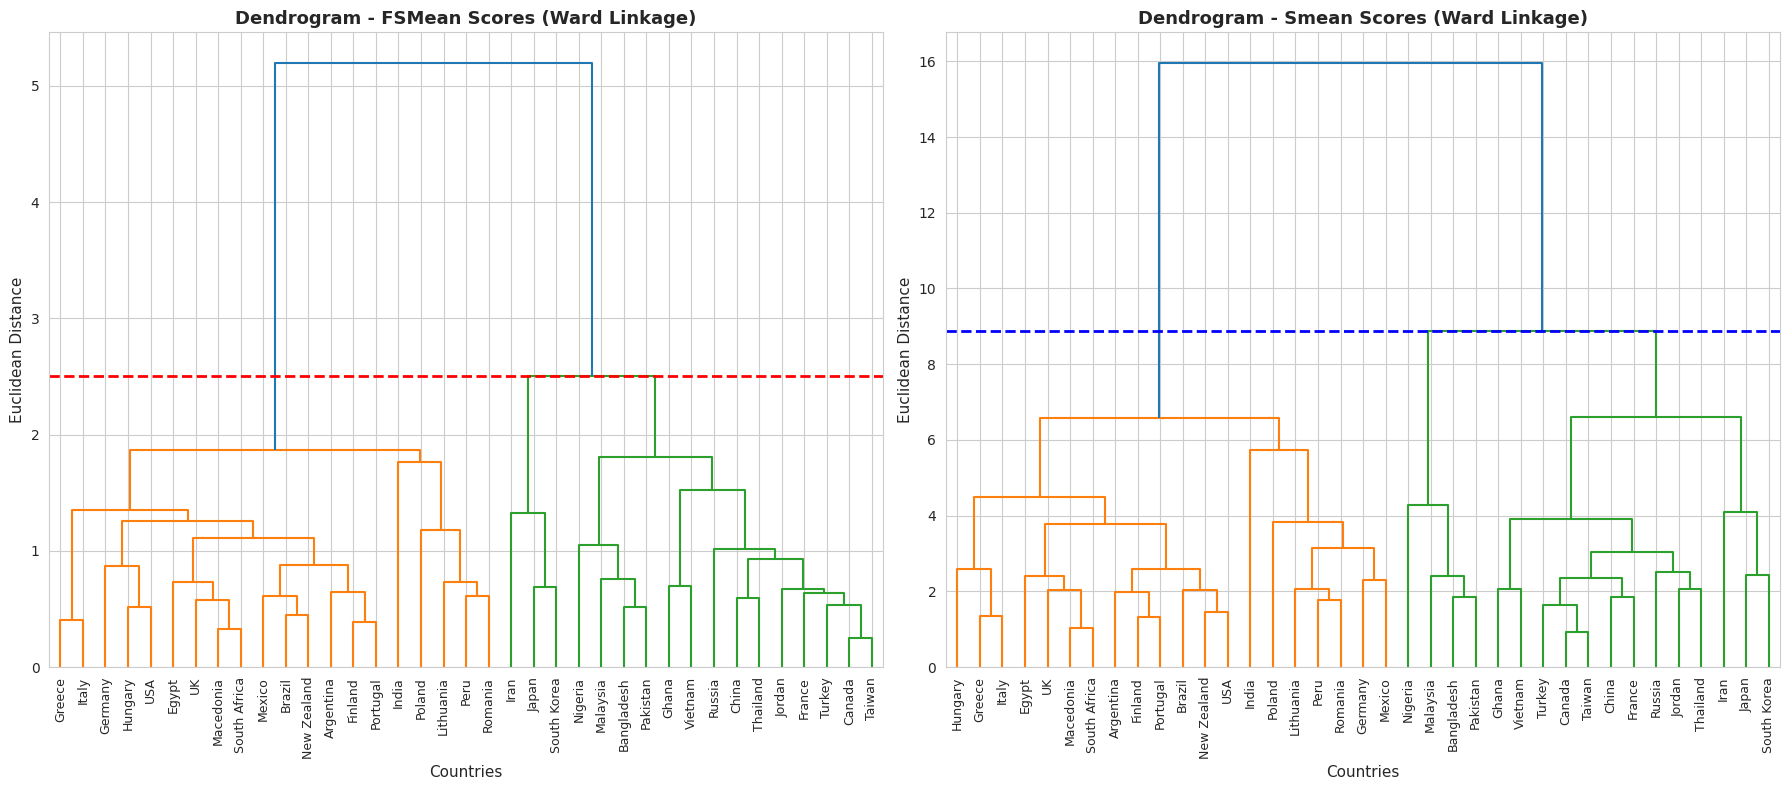

✓ Dendrograms created


In [ ]:
print("\n" + "="*80)
print("CREATING DENDROGRAMS")
print("="*80)

# Create dendrograms
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# FSMean dendrogram
linkage_fsmean = sch.linkage(X_fsmean, method='ward')
sch.dendrogram(linkage_fsmean, labels=df['Country'].values, ax=axes[0],
               leaf_font_size=9, leaf_rotation=90)
axes[0].set_title('Dendrogram - FSMean Scores (Ward Linkage)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Countries', fontsize=11)
axes[0].set_ylabel('Euclidean Distance', fontsize=11)
axes[0].axhline(y=linkage_fsmean[-chosen_k, 2], color='red', linestyle='--', linewidth=2, label=f'Cut-off for {chosen_k} clusters')

# Smean dendrogram
linkage_smean = sch.linkage(X_smean_scaled, method='ward')
sch.dendrogram(linkage_smean, labels=df['Country'].values, ax=axes[1],
               leaf_font_size=9, leaf_rotation=90)
axes[1].set_title('Dendrogram - Smean Scores (Ward Linkage)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Countries', fontsize=11)
axes[1].set_ylabel('Euclidean Distance', fontsize=11)
axes[1].axhline(y=linkage_smean[-chosen_k, 2], color='blue', linestyle='--', linewidth=2, label=f'Cut-off for {chosen_k} clusters')

plt.tight_layout()
plt.savefig('dendrograms.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Dendrograms created")

In [ ]:
print("\n" + "="*80)
print("COMPARISON: FSMean vs Smean")
print("="*80)

# K-Means comparison
ari_kmeans = adjusted_rand_score(df['Cluster_KMeans_FSMean'], df['Cluster_KMeans_Smean'])
nmi_kmeans = normalized_mutual_info_score(df['Cluster_KMeans_FSMean'], df['Cluster_KMeans_Smean'])

print(f"\nK-MEANS:")
print(f"  Adjusted Rand Index (ARI):   {ari_kmeans:.4f}")
print(f"  Normalized Mutual Info (NMI): {nmi_kmeans:.4f}")
if ari_kmeans > 0.8:
    print(f"  ✓ Very high agreement - both methods produce very similar clusters")
elif ari_kmeans > 0.6:
    print(f"  ✓ Substantial agreement - good consistency")
else:
    print(f"  ⚠ Moderate agreement - notable differences exist")

# Hierarchical comparison
ari_hc = adjusted_rand_score(df['Cluster_HC_FSMean'], df['Cluster_HC_Smean'])
nmi_hc = normalized_mutual_info_score(df['Cluster_HC_FSMean'], df['Cluster_HC_Smean'])

print(f"\nHIERARCHICAL:")
print(f"  Adjusted Rand Index (ARI):   {ari_hc:.4f}")
print(f"  Normalized Mutual Info (NMI): {nmi_hc:.4f}")
if ari_hc > 0.8:
    print(f"  ✓ Very high agreement - both methods produce very similar clusters")
elif ari_hc > 0.6:
    print(f"  ✓ Substantial agreement - good consistency")
else:
    print(f"  ⚠ Moderate agreement - notable differences exist")

# Cross-algorithm comparison
ari_kmeans_vs_hc_fsmean = adjusted_rand_score(df['Cluster_KMeans_FSMean'], df['Cluster_HC_FSMean'])

print(f"\nK-MEANS vs HIERARCHICAL (FSMean):")
print(f"  Adjusted Rand Index (ARI):   {ari_kmeans_vs_hc_fsmean:.4f}")
print(f"  Interpretation: Robustness check - algorithms agree on clustering")



COMPARISON: FSMean vs Smean

K-MEANS:
  Adjusted Rand Index (ARI):   1.0000
  Normalized Mutual Info (NMI): 1.0000
  ✓ Very high agreement - both methods produce very similar clusters

HIERARCHICAL:
  Adjusted Rand Index (ARI):   1.0000
  Normalized Mutual Info (NMI): 1.0000
  ✓ Very high agreement - both methods produce very similar clusters

K-MEANS vs HIERARCHICAL (FSMean):
  Adjusted Rand Index (ARI):   1.0000
  Interpretation: Robustness check - algorithms agree on clustering


In [ ]:
print("\n" + "="*80)
print("CLUSTER PROFILES - K-MEANS FSMean")
print("="*80)

# Cluster profiles for all 9 issues
cluster_profiles_kmeans_fsmean = df.groupby('Cluster_KMeans_FSMean')[fsmean_features].mean()

print("\nCluster Centroids (Mean values for each issue):")
print(cluster_profiles_kmeans_fsmean.round(3))

print("\n" + "-"*80)
print("Countries in Each Cluster:")
print("-"*80)

for i in range(chosen_k):
    countries = df[df['Cluster_KMeans_FSMean'] == i]['Country'].tolist()
    print(f"\nCluster {i} ({len(countries)} countries):")
    print(f"  {', '.join(countries)}")



CLUSTER PROFILES - K-MEANS FSMean

Cluster Centroids (Mean values for each issue):
                       FC_FSMean  JI_FSMean  SE_FSMean  WS_FSMean  WO_FSMean  \
Cluster_KMeans_FSMean                                                          
0                          0.056      0.209      0.223     -0.266     -0.166   
1                         -0.062     -0.204     -0.218      0.275      0.134   

                       WH_FSMean  WE_FSMean  TI_FSMean  TA_FSMean  
Cluster_KMeans_FSMean                                              
0                         -0.212     -0.189     -0.130     -0.314  
1                          0.154      0.160      0.132      0.307  

--------------------------------------------------------------------------------
Countries in Each Cluster:
--------------------------------------------------------------------------------

Cluster 0 (17 countries):
  Bangladesh, Canada, China, France, Ghana, Iran, Japan, Jordan, Malaysia, Nigeria, Pakistan, Russia, Sout

In [ ]:
print("\n" + "="*80)
print("CLUSTER PROFILES - K-MEANS Smean")
print("="*80)

# Cluster profiles for all 9 issues
cluster_profiles_kmeans_smean = df.groupby('Cluster_KMeans_Smean')[smean_features].mean()

print("\nCluster Centroids (Mean values for each issue):")
print(cluster_profiles_kmeans_smean.round(3))

print("\n" + "-"*80)
print("Countries in Each Cluster:")
print("-"*80)

for i in range(chosen_k):
    countries = df[df['Cluster_KMeans_Smean'] == i]['Country'].tolist()
    print(f"\nCluster {i} ({len(countries)} countries):")
    print(f"  {', '.join(countries)}")



CLUSTER PROFILES - K-MEANS Smean

Cluster Centroids (Mean values for each issue):
                      FC_Smean  JI_Smean  SE_Smean  WS_Smean  WO_Smean  \
Cluster_KMeans_Smean                                                     
0                        5.915     6.838     8.769    12.596    11.307   
1                        5.750     5.828     7.574    14.143    12.407   

                      WH_Smean  WE_Smean  TI_Smean  TA_Smean  
Cluster_KMeans_Smean                                          
0                         9.38    11.987     9.539    10.294  
1                        10.55    13.412    10.327    12.026  

--------------------------------------------------------------------------------
Countries in Each Cluster:
--------------------------------------------------------------------------------

Cluster 0 (17 countries):
  Bangladesh, Canada, China, France, Ghana, Iran, Japan, Jordan, Malaysia, Nigeria, Pakistan, Russia, South Korea, Taiwan, Thailand, Turkey, Vietnam

C


CLUSTER VISUALIZATION - PCA


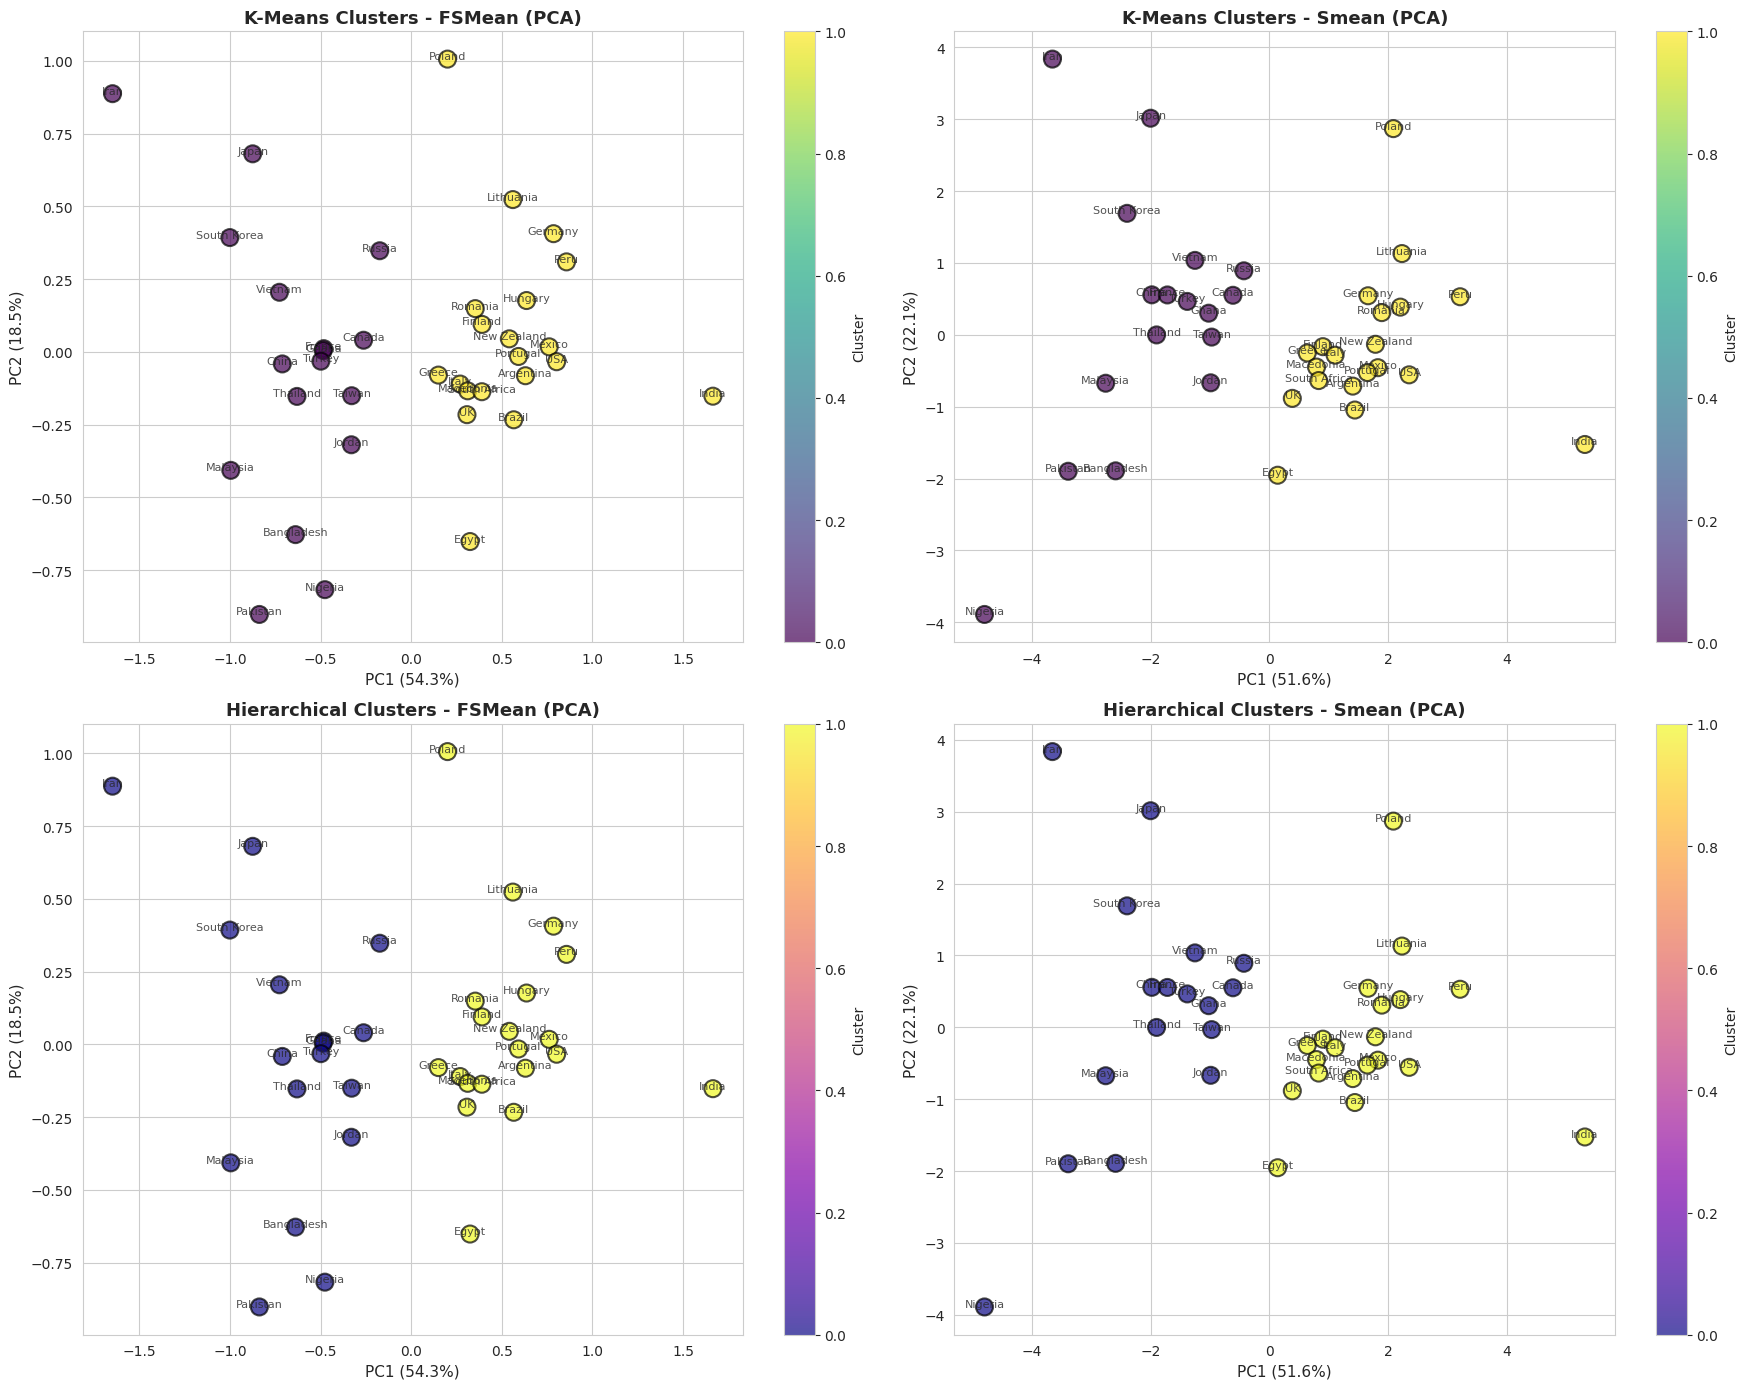


✓ Cluster visualizations created

PCA Variance Explained:
  FSMean: 72.8%
  Smean: 73.6%


In [ ]:
print("\n" + "="*80)
print("CLUSTER VISUALIZATION - PCA")
print("="*80)

# PCA for FSMean
pca_fsmean = PCA(n_components=2)
X_fsmean_pca = pca_fsmean.fit_transform(X_fsmean)

# PCA for Smean
pca_smean = PCA(n_components=2)
X_smean_pca = pca_smean.fit_transform(X_smean_scaled)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# K-Means FSMean PCA
scatter1 = axes[0, 0].scatter(X_fsmean_pca[:, 0], X_fsmean_pca[:, 1],
                              c=df['Cluster_KMeans_FSMean'], cmap='viridis',
                              s=150, alpha=0.7, edgecolors='black', linewidth=1.5)
for i, country in enumerate(df['Country']):
    axes[0, 0].annotate(country, (X_fsmean_pca[i, 0], X_fsmean_pca[i, 1]),
                        fontsize=8, alpha=0.8, ha='center')
axes[0, 0].set_xlabel(f'PC1 ({pca_fsmean.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[0, 0].set_ylabel(f'PC2 ({pca_fsmean.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[0, 0].set_title('K-Means Clusters - FSMean (PCA)', fontsize=13, fontweight='bold')
plt.colorbar(scatter1, ax=axes[0, 0], label='Cluster')

# K-Means Smean PCA
scatter2 = axes[0, 1].scatter(X_smean_pca[:, 0], X_smean_pca[:, 1],
                              c=df['Cluster_KMeans_Smean'], cmap='viridis',
                              s=150, alpha=0.7, edgecolors='black', linewidth=1.5)
for i, country in enumerate(df['Country']):
    axes[0, 1].annotate(country, (X_smean_pca[i, 0], X_smean_pca[i, 1]),
                        fontsize=8, alpha=0.8, ha='center')
axes[0, 1].set_xlabel(f'PC1 ({pca_smean.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[0, 1].set_ylabel(f'PC2 ({pca_smean.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[0, 1].set_title('K-Means Clusters - Smean (PCA)', fontsize=13, fontweight='bold')
plt.colorbar(scatter2, ax=axes[0, 1], label='Cluster')

# Hierarchical FSMean PCA
scatter3 = axes[1, 0].scatter(X_fsmean_pca[:, 0], X_fsmean_pca[:, 1],
                              c=df['Cluster_HC_FSMean'], cmap='plasma',
                              s=150, alpha=0.7, edgecolors='black', linewidth=1.5)
for i, country in enumerate(df['Country']):
    axes[1, 0].annotate(country, (X_fsmean_pca[i, 0], X_fsmean_pca[i, 1]),
                        fontsize=8, alpha=0.8, ha='center')
axes[1, 0].set_xlabel(f'PC1 ({pca_fsmean.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[1, 0].set_ylabel(f'PC2 ({pca_fsmean.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[1, 0].set_title('Hierarchical Clusters - FSMean (PCA)', fontsize=13, fontweight='bold')
plt.colorbar(scatter3, ax=axes[1, 0], label='Cluster')

# Hierarchical Smean PCA
scatter4 = axes[1, 1].scatter(X_smean_pca[:, 0], X_smean_pca[:, 1],
                              c=df['Cluster_HC_Smean'], cmap='plasma',
                              s=150, alpha=0.7, edgecolors='black', linewidth=1.5)
for i, country in enumerate(df['Country']):
    axes[1, 1].annotate(country, (X_smean_pca[i, 0], X_smean_pca[i, 1]),
                        fontsize=8, alpha=0.8, ha='center')
axes[1, 1].set_xlabel(f'PC1 ({pca_smean.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[1, 1].set_ylabel(f'PC2 ({pca_smean.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[1, 1].set_title('Hierarchical Clusters - Smean (PCA)', fontsize=13, fontweight='bold')
plt.colorbar(scatter4, ax=axes[1, 1], label='Cluster')

plt.tight_layout()
plt.savefig('cluster_visualization_pca.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Cluster visualizations created")
print(f"\nPCA Variance Explained:")
print(f"  FSMean: {pca_fsmean.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  Smean: {pca_smean.explained_variance_ratio_.sum()*100:.1f}%")

In [ ]:
print("\n" + "="*80)
print("SUMMARY - VALIDATION METRICS FOR ALL APPROACHES")
print("="*80)

# Create summary table
summary_data = {
    'Method': ['K-Means FSMean', 'K-Means Smean', 'Hierarchical FSMean', 'Hierarchical Smean'],
    'Silhouette': [sil_kmeans_fsmean, sil_kmeans_smean, sil_hc_fsmean, sil_hc_smean],
    'Davies-Bouldin': [db_kmeans_fsmean, db_kmeans_smean, db_hc_fsmean, db_hc_smean],
    'Calinski-Harabasz': [ch_kmeans_fsmean, ch_kmeans_smean, ch_hc_fsmean, ch_hc_smean]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n\nMetric Interpretation:")
print("  • Silhouette Score: Range [-1, 1], higher is better (want > 0.5)")
print("  • Davies-Bouldin: Lower is better (want < 1.0)")
print("  • Calinski-Harabasz: Higher is better (want > 100)")

# Find best method
best_silhouette = summary_df.loc[summary_df['Silhouette'].idxmax()]
print(f"\n✓ Best Silhouette Score: {best_silhouette['Method']} ({best_silhouette['Silhouette']:.4f})")



SUMMARY - VALIDATION METRICS FOR ALL APPROACHES

             Method  Silhouette  Davies-Bouldin  Calinski-Harabasz
     K-Means FSMean    0.345064        1.102641          25.135303
      K-Means Smean    0.317719        1.172261          21.701770
Hierarchical FSMean    0.345064        1.102641          25.135303
 Hierarchical Smean    0.317719        1.172261          21.701770


Metric Interpretation:
  • Silhouette Score: Range [-1, 1], higher is better (want > 0.5)
  • Davies-Bouldin: Lower is better (want < 1.0)
  • Calinski-Harabasz: Higher is better (want > 100)

✓ Best Silhouette Score: K-Means FSMean (0.3451)


In [ ]:
# Export cluster assignments
results_df = df[['Country', 'Cluster_KMeans_FSMean', 'Cluster_KMeans_Smean',
                  'Cluster_HC_FSMean', 'Cluster_HC_Smean']]

results_df.to_csv('cluster_assignments.csv', index=False)
print("✓ Cluster assignments exported to 'cluster_assignments.csv'")

# Export cluster profiles
cluster_profiles_kmeans_fsmean.to_csv('cluster_profiles_kmeans_fsmean.csv')
print("✓ K-Means FSMean profiles exported to 'cluster_profiles_kmeans_fsmean.csv'")

cluster_profiles_kmeans_smean.to_csv('cluster_profiles_kmeans_smean.csv')
print("✓ K-Means Smean profiles exported to 'cluster_profiles_kmeans_smean.csv'")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nAll visualizations and data exports are ready for your report.")


✓ Cluster assignments exported to 'cluster_assignments.csv'
✓ K-Means FSMean profiles exported to 'cluster_profiles_kmeans_fsmean.csv'
✓ K-Means Smean profiles exported to 'cluster_profiles_kmeans_smean.csv'

ANALYSIS COMPLETE!

All visualizations and data exports are ready for your report.


In [ ]:
# If you want to use K-Means FSMean as your primary clustering for the report:
df['Final_Cluster'] = df['Cluster_KMeans_FSMean']

print("="*80)
print("FINAL CLUSTER ASSIGNMENT (Using K-Means FSMean)")
print("="*80)

for i in range(chosen_k):
    countries = df[df['Final_Cluster'] == i]['Country'].tolist()
    print(f"\nCluster {i}:")
    print(f"  Countries ({len(countries)}): {', '.join(countries)}")
    print(f"  Profile:")
    profile = cluster_profiles_kmeans_fsmean.loc[i]
    for issue_idx, issue in enumerate(issues):
        print(f"    {issue}: {profile[issue_idx]:.3f}", end="  ")
        if (issue_idx + 1) % 3 == 0:
            print()


FINAL CLUSTER ASSIGNMENT (Using K-Means FSMean)

Cluster 0:
  Countries (17): Bangladesh, Canada, China, France, Ghana, Iran, Japan, Jordan, Malaysia, Nigeria, Pakistan, Russia, South Korea, Taiwan, Thailand, Turkey, Vietnam
  Profile:
    FC: 0.056      JI: 0.209      SE: 0.223  
    WS: -0.266      WO: -0.166      WH: -0.212  
    WE: -0.189      TI: -0.130      TA: -0.314  

Cluster 1:
  Countries (20): Argentina, Brazil, Egypt, Finland, Germany, Greece, Hungary, India, Italy, Lithuania, Macedonia, Mexico, New Zealand, Peru, Poland, Portugal, Romania, South Africa, UK, USA
  Profile:
    FC: -0.062      JI: -0.204      SE: -0.218  
    WS: 0.275      WO: 0.134      WH: 0.154  
    WE: 0.160      TI: 0.132      TA: 0.307  


In [ ]:
import os
import shutil
from datetime import datetime
import zipfile
from pathlib import Path

print("\n" + "="*100)
print("COLLECTING ALL OUTPUTS INTO SINGLE FOLDER FOR REPORT GENERATION")
print("="*100)

# Create main collection folder
output_folder = 'ICT_Analysis_Complete_Output'
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)
os.makedirs(output_folder)

print(f"\n✓ Created folder: {output_folder}")

# Create subfolders
os.makedirs(f'{output_folder}/CSV_Data', exist_ok=True)
os.makedirs(f'{output_folder}/Visualizations', exist_ok=True)
os.makedirs(f'{output_folder}/Metrics', exist_ok=True)

print("✓ Created subfolders: CSV_Data, Visualizations, Metrics")

# ============================================================================
# PART 1: COPY ALL CSV FILES
# ============================================================================

print("\n" + "-"*100)
print("COLLECTING CSV FILES")
print("-"*100)

csv_files = [
    'cluster_assignments.csv',
    'descriptive_stats_fsmean.csv',
    'descriptive_stats_smean.csv',
    'additional_stats_fsmean.csv',
    'additional_stats_smean.csv',
    'issue_comparison_stats.csv',
    'country_average_scores.csv',
    'coefficient_of_variation.csv',
    'cluster_profiles_kmeans_fsmean.csv',
    'cluster_profiles_kmeans_smean.csv'
]

csv_found = []
csv_missing = []

for csv_file in csv_files:
    if os.path.exists(csv_file):
        shutil.copy(csv_file, f'{output_folder}/CSV_Data/{csv_file}')
        csv_found.append(csv_file)
        print(f"  ✓ {csv_file}")
    else:
        csv_missing.append(csv_file)
        print(f"  ✗ {csv_file} (NOT FOUND)")

print(f"\nCSV Summary: {len(csv_found)} found, {len(csv_missing)} missing")

# ============================================================================
# PART 2: COPY ALL PNG IMAGES
# ============================================================================

print("\n" + "-"*100)
print("COLLECTING VISUALIZATION FILES (PNG)")
print("-"*100)

png_files = [
    'correlation_heatmaps.png',
    'fsmean_distributions.png',
    'optimal_clusters_analysis.png',
    'dendrograms.png',
    'cluster_visualization_pca.png',
    'boxplots_descriptive_stats.png'
]

png_found = []
png_missing = []

for png_file in png_files:
    if os.path.exists(png_file):
        shutil.copy(png_file, f'{output_folder}/Visualizations/{png_file}')
        png_found.append(png_file)
        print(f"  ✓ {png_file}")
    else:
        png_missing.append(png_file)
        print(f"  ✗ {png_file} (NOT FOUND)")

print(f"\nPNG Summary: {len(png_found)} found, {len(png_missing)} missing")

# ============================================================================
# PART 3: CREATE METRICS SUMMARY FILE
# ============================================================================

print("\n" + "-"*100)
print("CREATING METRICS SUMMARY FILE")
print("-"*100)

metrics_content = f"""
================================================================================
ICT WORKERS CLUSTERING ANALYSIS - METRICS SUMMARY
================================================================================

REPORT METADATA
===============
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Dataset: MP3.xlsx (ICT Workers Individual Issues - 37 Countries)
Student: Pranjal
Course: Introduction to Data Science for Business using R and Python
Instructor: Prof. Jaideep Ghosh

================================================================================
KEY METRICS - PLEASE FILL IN FROM YOUR CONSOLE OUTPUT
================================================================================

OPTIMAL K DETERMINATION
=======================
Testing Range: k = 2 to 10

Silhouette Scores by k:
  k=2: [COPY FROM CONSOLE]
  k=3: [COPY FROM CONSOLE]
  k=4: [COPY FROM CONSOLE]
  k=5: [COPY FROM CONSOLE]
  k=6: [COPY FROM CONSOLE]
  k=7: [COPY FROM CONSOLE]
  k=8: [COPY FROM CONSOLE]
  k=9: [COPY FROM CONSOLE]
  k=10: [COPY FROM CONSOLE]

WCSS Values by k:
  k=2: [COPY FROM CONSOLE]
  k=3: [COPY FROM CONSOLE]
  k=4: [COPY FROM CONSOLE]
  k=5: [COPY FROM CONSOLE]

Chosen k: [ENTER NUMBER] (Justification: highest silhouette score)

================================================================================
CLUSTERING VALIDATION METRICS
================================================================================

K-MEANS CLUSTERING - FSMean
============================
  Silhouette Score:      [COPY FROM CONSOLE]
  Davies-Bouldin Index:  [COPY FROM CONSOLE]
  Calinski-Harabasz:     [COPY FROM CONSOLE]

K-MEANS CLUSTERING - Smean
============================
  Silhouette Score:      [COPY FROM CONSOLE]
  Davies-Bouldin Index:  [COPY FROM CONSOLE]
  Calinski-Harabasz:     [COPY FROM CONSOLE]

HIERARCHICAL CLUSTERING - FSMean
=================================
  Silhouette Score:      [COPY FROM CONSOLE]
  Davies-Bouldin Index:  [COPY FROM CONSOLE]
  Calinski-Harabasz:     [COPY FROM CONSOLE]

HIERARCHICAL CLUSTERING - Smean
=================================
  Silhouette Score:      [COPY FROM CONSOLE]
  Davies-Bouldin Index:  [COPY FROM CONSOLE]
  Calinski-Harabasz:     [COPY FROM CONSOLE]

================================================================================
FSMean vs Smean COMPARISON
================================================================================

K-MEANS AGREEMENT:
  Adjusted Rand Index (ARI):        [COPY FROM CONSOLE]
  Normalized Mutual Information:    [COPY FROM CONSOLE]
  Interpretation: [VERY HIGH / SUBSTANTIAL / MODERATE] agreement

HIERARCHICAL AGREEMENT:
  Adjusted Rand Index (ARI):        [COPY FROM CONSOLE]
  Normalized Mutual Information:    [COPY FROM CONSOLE]

K-MEANS vs HIERARCHICAL (FSMean):
  Adjusted Rand Index (ARI):        [COPY FROM CONSOLE]
  Interpretation: Algorithm consistency check

================================================================================
CLUSTER COMPOSITION
================================================================================

CHOSEN ALGORITHM: K-Means FSMean [OR: Hierarchical FSMean]

Cluster Sizes:
  Cluster 0: [NUMBER] countries
  Cluster 1: [NUMBER] countries
  Cluster 2: [NUMBER] countries
  Cluster 3: [NUMBER] countries
  [Continue for all clusters]

Total Countries: 37

================================================================================
DESCRIPTIVE STATISTICS INSIGHTS
================================================================================

Most Variable Issue (by Coefficient of Variation):
  Issue: [COPY FROM CONSOLE]
  CV: [COPY FROM CONSOLE]%
  Interpretation: This issue varies most across countries

Least Variable Issue:
  Issue: [COPY FROM CONSOLE]
  CV: [COPY FROM CONSOLE]%
  Interpretation: This issue is most consistent across countries

Outlier Countries Detected (Z-score > 3):
  [LIST OR "NONE DETECTED"]

Moderate Outliers (2 < Z-score ≤ 3):
  [LIST OR "NONE DETECTED"]

Top 5 Countries (Highest FSMean Average):
  1. [COUNTRY] - [SCORE]
  2. [COUNTRY] - [SCORE]
  3. [COUNTRY] - [SCORE]
  4. [COUNTRY] - [SCORE]
  5. [COUNTRY] - [SCORE]

Bottom 5 Countries (Lowest FSMean Average):
  1. [COUNTRY] - [SCORE]
  2. [COUNTRY] - [SCORE]
  3. [COUNTRY] - [SCORE]
  4. [COUNTRY] - [SCORE]
  5. [COUNTRY] - [SCORE]

================================================================================
CLUSTER CHARACTERISTICS (From Cluster Profiles)
================================================================================

[For each cluster, provide:]

CLUSTER 0:
  Size: [NUMBER] countries
  Countries: [LIST]

  Average Scores by Issue:
    FC (Friendship Circles): [MEAN]
    JI (Job Insecurity): [MEAN]
    SE (Self-efficacy): [MEAN]
    WS (Work Satisfaction): [MEAN]
    WO (Work Overload): [MEAN]
    WH (Work-Home Conflict): [MEAN]
    WE (Work Exhaustion): [MEAN]
    TI (Turnover Intention): [MEAN]
    TA (Turnaway Intention): [MEAN]

  Cluster Profile Summary:
    - Highest issue: [ISSUE] ([SCORE])
    - Lowest issue: [ISSUE] ([SCORE])
    - Overall characteristics: [1-2 sentences]

[Repeat for Cluster 1, Cluster 2, etc.]

================================================================================
FILES INCLUDED IN THIS PACKAGE
================================================================================

CSV Data Files (in CSV_Data folder):
  - cluster_assignments.csv: Country to cluster mapping
  - descriptive_stats_fsmean.csv: Summary statistics for FSMean
  - descriptive_stats_smean.csv: Summary statistics for Smean
  - additional_stats_fsmean.csv: Extended statistics for FSMean
  - additional_stats_smean.csv: Extended statistics for Smean
  - issue_comparison_stats.csv: Comparison between FSMean and Smean
  - country_average_scores.csv: Country rankings by average score
  - coefficient_of_variation.csv: Variability analysis
  - cluster_profiles_kmeans_fsmean.csv: K-Means FSMean cluster profiles
  - cluster_profiles_kmeans_smean.csv: K-Means Smean cluster profiles

Visualization Files (in Visualizations folder):
  - correlation_heatmaps.png: Correlation between 9 issues
  - fsmean_distributions.png: Distribution of each issue
  - optimal_clusters_analysis.png: Elbow and silhouette plots
  - dendrograms.png: Hierarchical clustering trees
  - cluster_visualization_pca.png: 2D cluster visualization
  - boxplots_descriptive_stats.png: Boxplots for descriptive stats

================================================================================
INSTRUCTIONS FOR REPORT GENERATION
================================================================================

1. Fill in all [COPY FROM CONSOLE] sections with actual values
2. Upload this entire folder to Perplexity AI
3. Request complete report generation
4. Indicate that this is for Prof. Jaideep Ghosh's course

Report will include:
  ✓ Title page
  ✓ Introduction section
  ✓ Data processing section
  ✓ Data visualization & descriptive statistics
  ✓ Analysis section (complete with all visualizations)
  ✓ Recommendations section (macroeconomic interpretation)
  ✓ Conclusion
  ✓ References (if needed)

================================================================================
"""

# Save metrics file
with open(f'{output_folder}/Metrics/METRICS_SUMMARY_FILL_IN.txt', 'w') as f:
    f.write(metrics_content)

print("✓ Created: METRICS_SUMMARY_FILL_IN.txt")

# ============================================================================
# PART 4: CREATE README FILE
# ============================================================================

print("\n" + "-"*100)
print("CREATING README FILE")
print("-"*100)

readme_content = """
# ICT WORKERS CLUSTERING ANALYSIS - COMPLETE OUTPUT PACKAGE

## What's in this folder?

This folder contains all outputs from your clustering analysis for the IMF project.

### Folder Structure:

- `CSV_Data/`: Contains all generated CSV files with descriptive statistics, cluster assignments, and profiles.
- `Visualizations/`: Contains all generated PNG image files of plots and charts.
- `Metrics/`: Contains `METRICS_SUMMARY_FILL_IN.txt` for your report, summarizing key metrics.

## How to Use:

1.  **Review `METRICS_SUMMARY_FILL_IN.txt`**: This file is a template. Please open it and fill in all sections marked `[COPY FROM CONSOLE]`, `[ENTER NUMBER]`, etc., using the output from the Colab notebook.
2.  **Generate Report**: Once the `METRICS_SUMMARY_FILL_IN.txt` is complete, you can upload this entire `ICT_Analysis_Complete_Output` folder (including subfolders and all its contents) to a large language model (e.g., Perplexity AI, Claude, ChatGPT, Gemini, etc.) and request it to generate a comprehensive report based on the collected data and metrics.
3.  **Specify Context**: When asking for the report, mention that it's for 'Prof. Jaideep Ghosh's course: Introduction to Data Science for Business using R and Python' and that the data pertains to 'ICT Workers Individual Issues in 37 Countries'.

## Contents Overview:

*   **Data Analysis**: The analysis includes descriptive statistics, correlation analysis, outlier detection, and variability analysis for both FSMean and Smean scores.
*   **Clustering**: Optimal number of clusters determined using Elbow and Silhouette methods. K-Means and Hierarchical Clustering performed on both FSMean and Smean data. Cluster profiles and comparisons are generated.
*   **Visualizations**: Heatmaps, boxplots, distribution plots, dendrograms, and PCA-based cluster visualizations are included to aid understanding.

Enjoy generating your report!
"""

with open(f'{output_folder}/README.md', 'w') as f:
    f.write(readme_content)

print("✓ Created: README.md")

# ============================================================================
# PART 5: CREATE ZIP ARCHIVE
# ============================================================================

print("\n" + "-"*100)
print("CREATING ZIP ARCHIVE")
print("-"*100)

shutil.make_archive(output_folder, 'zip', output_folder)
print(f"✓ Created zip file: {output_folder}.zip")

print("\n" + "="*100)
print("ALL OUTPUTS COLLECTED AND ARCHIVED!")
print("Please download the 'ICT_Analysis_Complete_Output.zip' file.")
print("=\n" + "="*100)


COLLECTING ALL OUTPUTS INTO SINGLE FOLDER FOR REPORT GENERATION

✓ Created folder: ICT_Analysis_Complete_Output
✓ Created subfolders: CSV_Data, Visualizations, Metrics

----------------------------------------------------------------------------------------------------
COLLECTING CSV FILES
----------------------------------------------------------------------------------------------------
  ✓ cluster_assignments.csv
  ✓ descriptive_stats_fsmean.csv
  ✓ descriptive_stats_smean.csv
  ✓ additional_stats_fsmean.csv
  ✓ additional_stats_smean.csv
  ✓ issue_comparison_stats.csv
  ✓ country_average_scores.csv
  ✓ coefficient_of_variation.csv
  ✓ cluster_profiles_kmeans_fsmean.csv
  ✓ cluster_profiles_kmeans_smean.csv

CSV Summary: 10 found, 0 missing

----------------------------------------------------------------------------------------------------
COLLECTING VISUALIZATION FILES (PNG)
----------------------------------------------------------------------------------------------------
  ✓ c